# Week 3 — Global Market Segmentation & Country Risk Intelligence System

**Dataset:** `dataset_country.csv` · 167 countries · 9 socioeconomic features  
**Target:** Market segment classification via clustering-then-classification pipeline  
**Pipeline:** EDA → Preprocessing → PCA → K-Means → DBSCAN → Random Forest → XGBoost → Business Insights

> **Note:** This dataset contains no pre-existing labels. K-Means discovers 
> natural country groupings; those cluster labels become the classification target 
> for ensemble models.

## Loading Libraries

In [277]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, silhouette_score,f1_score, accuracy_score)
from xgboost import XGBClassifier

print("All Imports completed.")

All Imports completed.


## Dataset Loading and Inspection

In [278]:
df = pd.read_csv("datasets/dataset_country.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nNull values:\n", df.isna().sum())
print("\nData Type\n", df.dtypes)
print("\nDuplicates:", df.duplicated().sum())
df.head()

Shape: (167, 10)

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Null values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Data Type
 country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Duplicates: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [279]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Exploratory Data Analysis

### Correlation Analysis
Values close to:
- +1 indicate strong positive correlation
- -1 indicate strong negative correlation
- 0 indicate little or no linear relationship

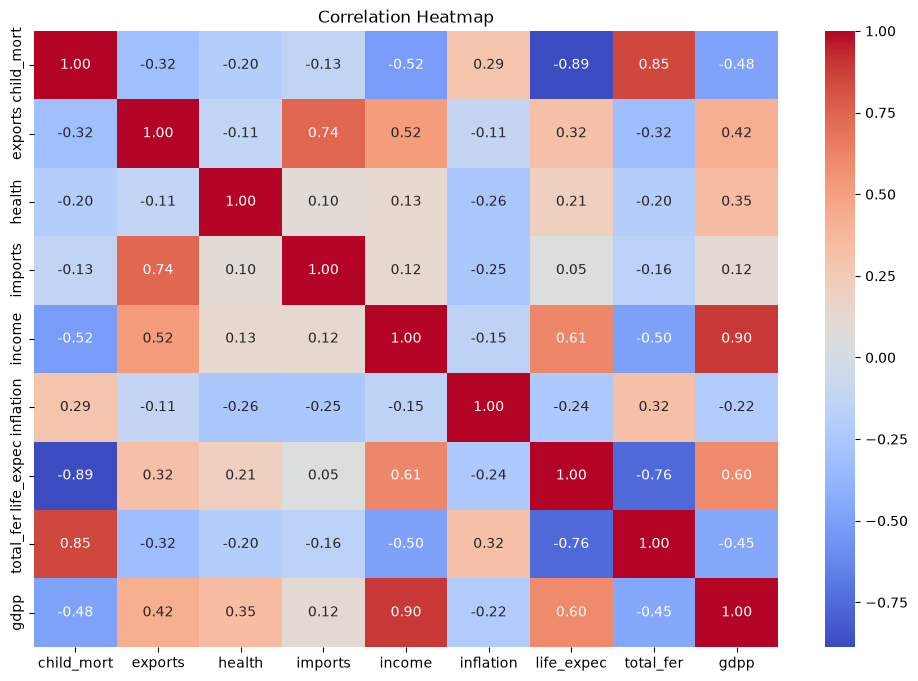

In [280]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Feature Distributions

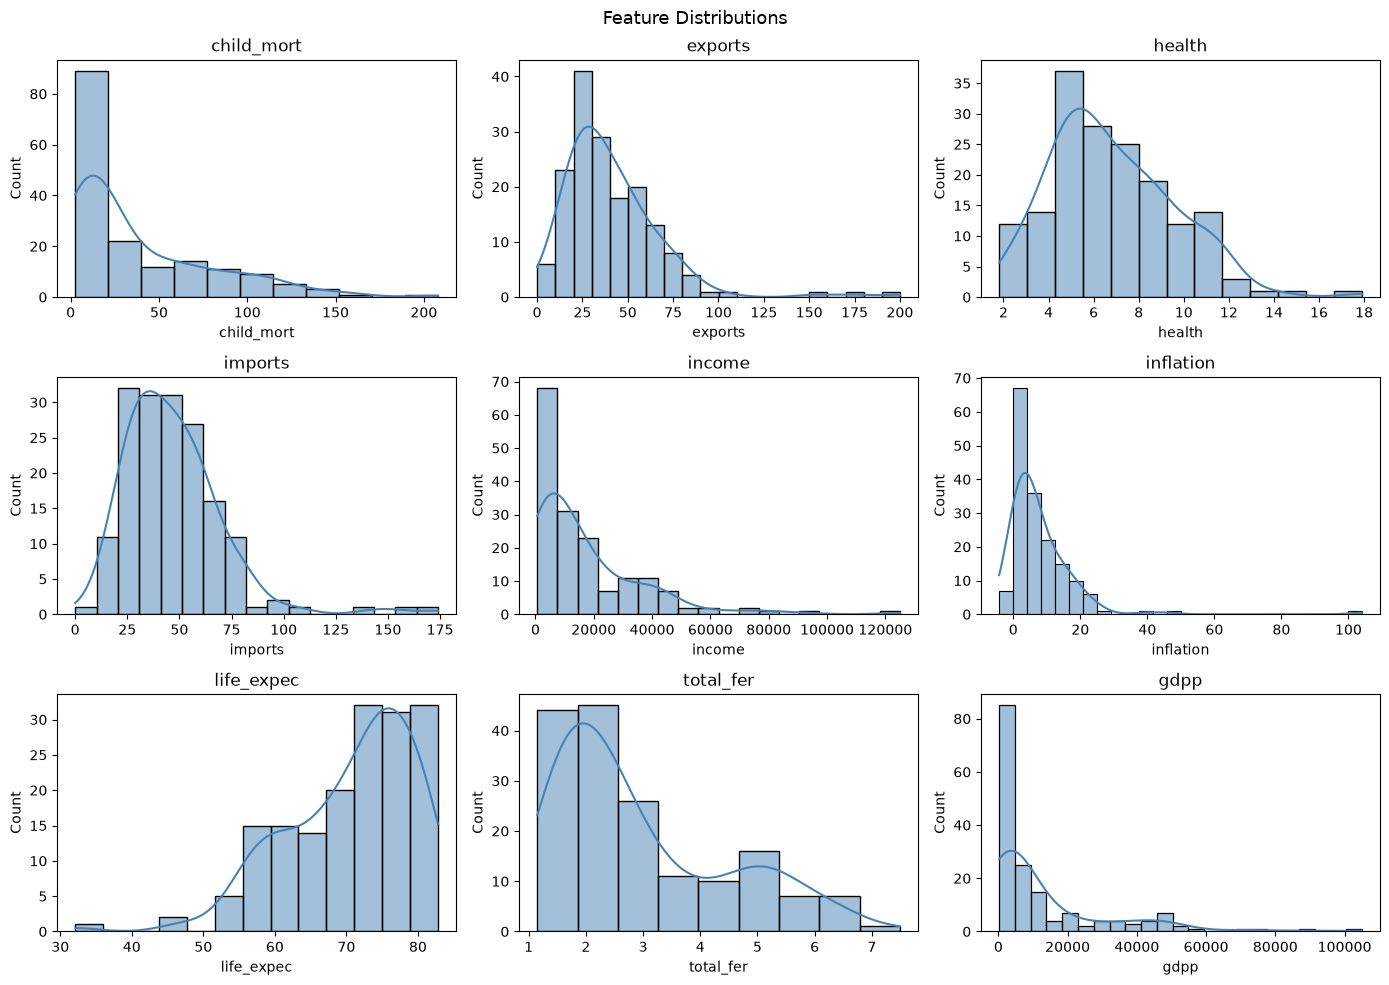

In [281]:
features = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

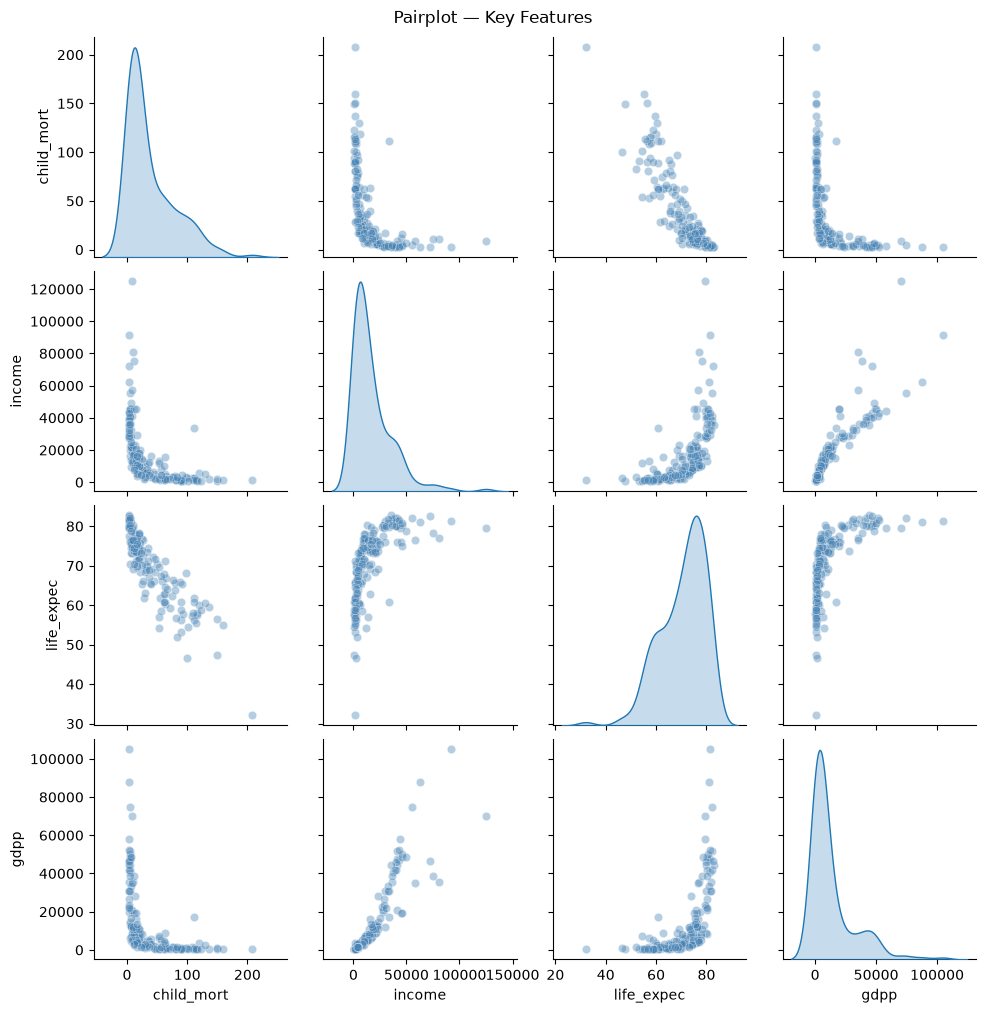

In [282]:
sns.pairplot(df[['child_mort', 'income', 'life_expec', 'gdpp']], diag_kind='kde', plot_kws={'alpha': 0.4, 'color': 'steelblue'})
plt.suptitle('Pairplot — Key Features', y=1.01)
plt.show()

## Preprocessing
Features operate on vastly different scales (`gdpp` in thousands, `child_mort` in tens). 
`StandardScaler` normalises all features to zero mean and unit variance — 
non-negotiable for distance-based algorithms like K-Means and DBSCAN.

In [283]:
country_names = df['country']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Scaled shape:", X_scaled.shape)
print("Mean:", X_scaled.mean(axis=0))

Scaled shape: (167, 9)
Mean: [-3.72290356e-17  2.12737346e-16  5.50457883e-16  2.76558550e-16
 -7.97765048e-17 -1.06368673e-17  3.69631139e-16  3.04480327e-16
  5.85027702e-17]


## Principal Component Analysis (PCA)

Reducing 9 features to 2 principal components for visualisation. 
PCA also serves as a sanity check — if two components explain >60% of variance, 
the dataset has strong underlying structure suitable for clustering.

Explained variance ratio: [0.46  0.172]
Total variance explained: 0.631


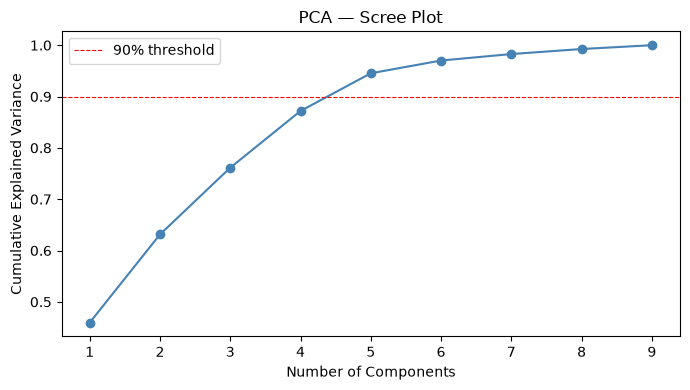

In [284]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total variance explained:", pca.explained_variance_ratio_.sum().round(3))

# Scree plot
pca_full = PCA(random_state=42).fit(X_scaled)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(features)+1), np.cumsum(pca_full.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(0.90, color='red', linestyle='--', linewidth=0.8, label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Scree Plot')
plt.legend()
plt.tight_layout()
plt.show()

## K-Means Clustering

### Optimal k Selection — Elbow Method & Silhouette Score

Running K-Means for k = 2 to 10. The elbow method minimises inertia (within-cluster 
sum of squares); silhouette score measures how well-separated clusters are. 
We select k where silhouette peaks.

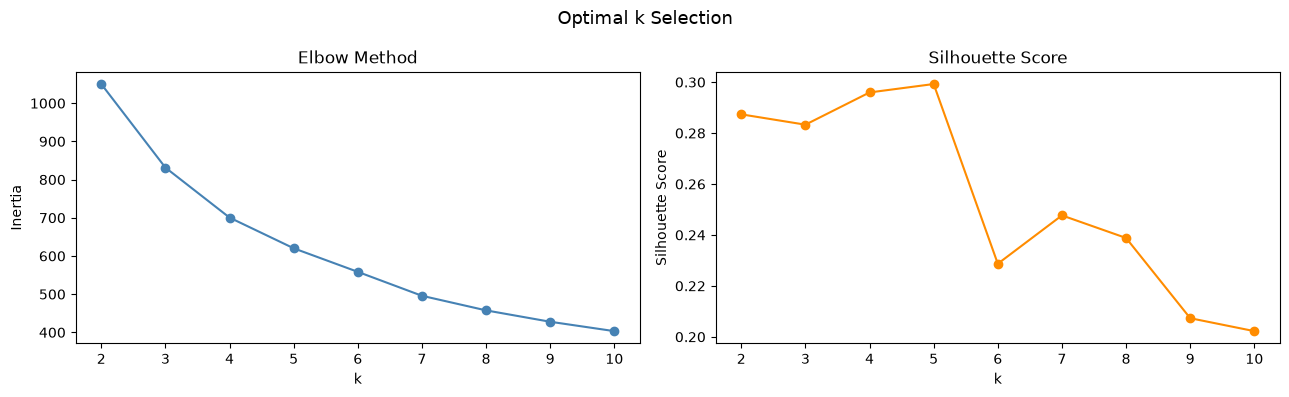

Best k by silhouette: 5


In [285]:
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Optimal k Selection', fontsize=13)
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}")

In [286]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = km_final.fit_predict(X_scaled)

print("Cluster counts:\n", df['KMeans_Cluster'].value_counts().sort_index())
print(f"\nFinal silhouette score: {silhouette_score(X_scaled, df['KMeans_Cluster']):.4f}")

Cluster counts:
 KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64

Final silhouette score: 0.2833


### Cluster Visualisation in PCA Space

Projecting clusters onto the first two principal components (63.2% variance explained). 
Notable countries are annotated to validate that cluster assignments are geographically 
and economically coherent.

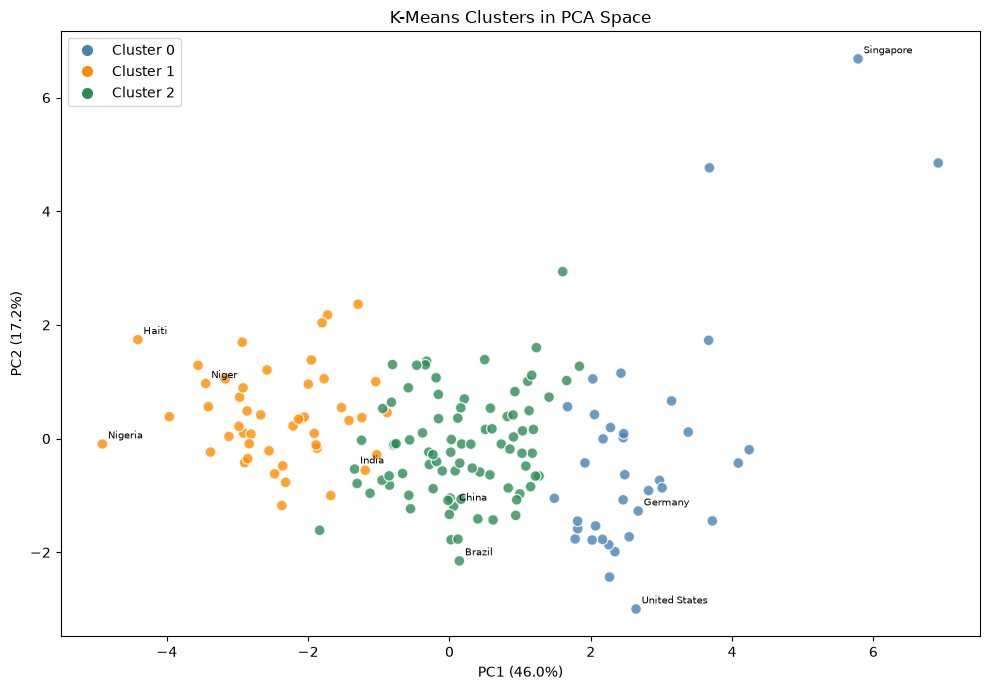

In [287]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = {0: 'steelblue', 1: 'darkorange', 2: 'seagreen'}
colors  = df['KMeans_Cluster'].map(palette)

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, alpha=0.8, edgecolors='white')

# Annotate a handful of notable countries
annotate = ['United States', 'China', 'India', 'Germany',
            'Haiti', 'Niger', 'Singapore', 'Brazil', 'Nigeria']
for i, name in enumerate(country_names):
    if name in annotate:
        ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]),
                    fontsize=7.5, xytext=(4, 4), textcoords='offset points')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=9, label=f'Cluster {k}') for k, c in palette.items()]
ax.legend(handles=handles)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Means Clusters in PCA Space')
plt.tight_layout()
plt.show()

## DBSCAN Clustering

Using a k-distance plot to select `eps` before fitting. DBSCAN is included 
as a contrast to K-Means — it does not require specifying k upfront and 
naturally identifies outliers as noise points.

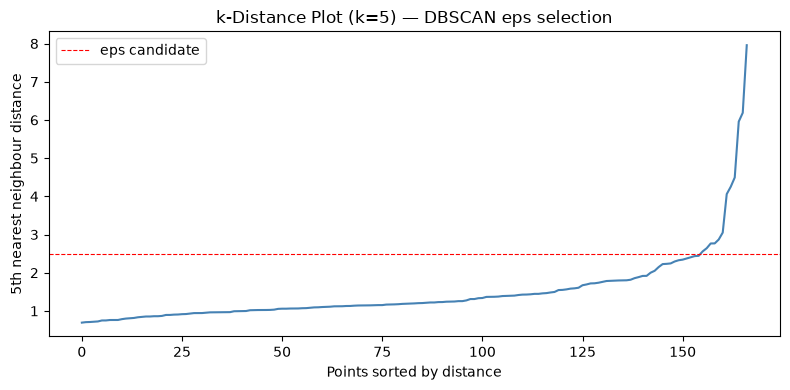

In [288]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='steelblue')
plt.axhline(y=2.5, color='red', linestyle='--', linewidth=0.8, label='eps candidate')
plt.title('k-Distance Plot (k=5) — DBSCAN eps selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbour distance')
plt.legend()
plt.tight_layout()
plt.show()

In [289]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise    = (df['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN clusters found : {n_clusters}")
print(f"Noise points (−1)     : {n_noise}")
print("\nCluster counts:\n", df['DBSCAN_Cluster'].value_counts().sort_index())

print("\nOutlier countries:")
print(country_names[df['DBSCAN_Cluster'] == -1].values)

DBSCAN clusters found : 1
Noise points (−1)     : 6

Cluster counts:
 DBSCAN_Cluster
-1      6
 0    161
Name: count, dtype: int64

Outlier countries:
<StringArray>
['Haiti', 'Luxembourg', 'Malta', 'Nigeria', 'Qatar', 'Singapore']
Length: 6, dtype: str


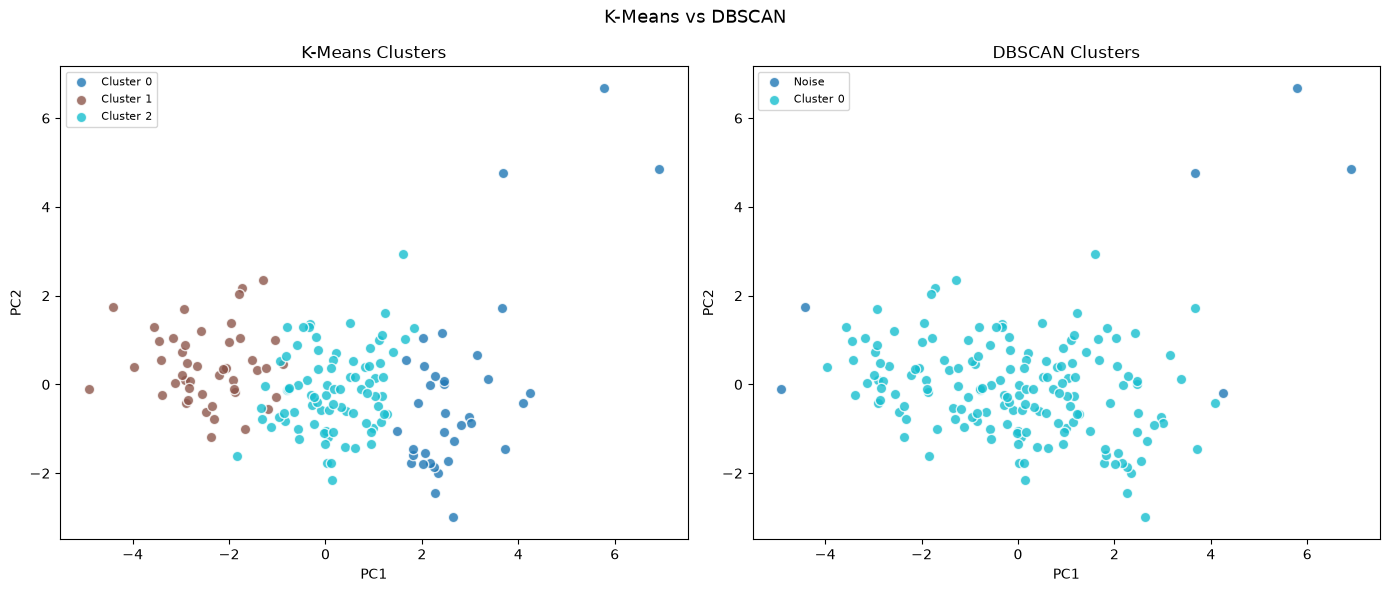

In [290]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(axes, ['KMeans_Cluster', 'DBSCAN_Cluster'], ['K-Means', 'DBSCAN']):
    unique = sorted(df[col].unique())
    cmap   = plt.colormaps['tab10'].resampled(len(unique))
    for i, label in enumerate(unique):
        mask = df[col] == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],color=cmap(i), s=55, alpha=0.8, edgecolors='white',label='Noise' if label == -1 else f'Cluster {label}')
    ax.set_title(f'{title} Clusters')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.suptitle('K-Means vs DBSCAN', fontsize=13)
plt.tight_layout()
plt.show()

KMeans_Cluster         0        1         2
child_mort          5.00    92.96     21.93
exports            58.74    29.15     40.24
health              8.81     6.39      6.20
imports            51.49    42.32     47.47
income          45672.22  3942.40  12305.60
inflation           2.67    12.02      7.60
life_expec         80.13    59.19     72.81
total_fer           1.75     5.01      2.31
gdpp            42494.44  1922.38   6486.45


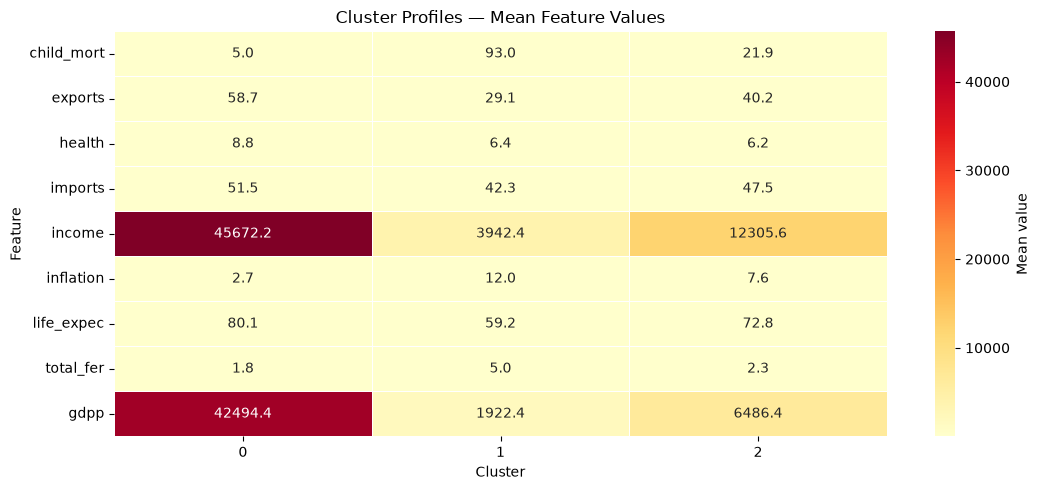

In [291]:
profile = df.groupby('KMeans_Cluster')[features].mean().round(2)
print(profile.T.to_string())

plt.figure(figsize=(11, 5))
sns.heatmap(profile.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean value'})
plt.title('Cluster Profiles — Mean Feature Values')
plt.ylabel('Feature')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

### Segment Naming

Based on the cluster profiles:
- **Cluster 0** → high GDP, high income, low child mortality → **Developed Markets**
- **Cluster 1** → low GDP, low income, high child mortality → **Underdeveloped Markets**  
- **Cluster 2** → mid-range across all indicators → **Developing Markets**

In [292]:
segment_map = {
    0: 'Developed Markets',
    1: 'Underdeveloped Markets',
    2: 'Developing Markets',
}
df['Segment'] = df['KMeans_Cluster'].map(segment_map)

print(df.groupby('Segment').size().rename('Country count'))
print()
for seg, grp in df.groupby('Segment'):
    print(f"{seg}: {', '.join(grp['country'].values[:6])} ...")

Segment
Developed Markets         36
Developing Markets        84
Underdeveloped Markets    47
Name: Country count, dtype: int64

Developed Markets: Australia, Austria, Bahrain, Belgium, Brunei, Canada ...
Developing Markets: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan ...
Underdeveloped Markets: Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi ...


## 8. Classification on Cluster Labels

Using K-Means cluster assignments as the target variable, we train ensemble 
classifiers to learn the boundary between market segments. This enables 
prediction of segment membership for any new country given its socioeconomic indicators.

In [293]:
X_cls = X_scaled
y_cls = df['KMeans_Cluster'].values

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (133, 9)  |  Test: (34, 9)


### Random Forest Classification

In [294]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Classification Report for Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=list(segment_map.values())))

Classification Report for Random Forest
                        precision    recall  f1-score   support

     Developed Markets       1.00      1.00      1.00         7
Underdeveloped Markets       1.00      1.00      1.00        10
    Developing Markets       1.00      1.00      1.00        17

              accuracy                           1.00        34
             macro avg       1.00      1.00      1.00        34
          weighted avg       1.00      1.00      1.00        34



### XGBoost Classification

In [295]:
xgb_clf = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("Classification Report for XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=list(segment_map.values())))

Classification Report for XGBoost
                        precision    recall  f1-score   support

     Developed Markets       1.00      0.86      0.92         7
Underdeveloped Markets       1.00      0.90      0.95        10
    Developing Markets       0.89      1.00      0.94        17

              accuracy                           0.94        34
             macro avg       0.96      0.92      0.94        34
          weighted avg       0.95      0.94      0.94        34



### Confusion Matrices

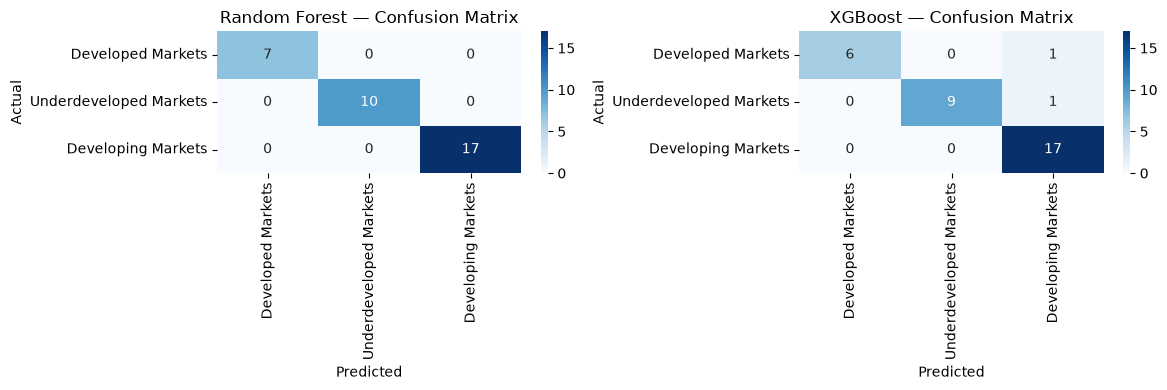

In [296]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(axes, [y_pred_rf, y_pred_xgb], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=segment_map.values(),
                yticklabels=segment_map.values())
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

#### Boundry Case Analysis - XGBoost Misclassifications

In [297]:
X_train_idx, X_test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42,
    stratify=df['KMeans_Cluster']
)

misclassified = df.loc[X_test_idx].copy()
misclassified['Predicted'] = [segment_map[p] for p in y_pred_xgb]
misclassified = misclassified[misclassified['Segment'] != misclassified['Predicted']]

print("Misclassified countries:")
print(misclassified[['country', 'Segment', 'Predicted', 'gdpp', 'income', 'life_expec']])

Misclassified countries:
     country                 Segment           Predicted   gdpp  income  \
21  Botswana  Underdeveloped Markets  Developing Markets   6350   13300   
82    Kuwait       Developed Markets  Developing Markets  38500   75200   

    life_expec  
21        57.1  
82        78.2  


### Cross-Validation
5-fold CV on the full dataset to get a robust generalisation estimate.

In [298]:
for clf, name in [(rf_clf, 'Random Forest'), (xgb_clf, 'XGBoost')]:
    scores = cross_val_score(clf, X_cls, y_cls, cv=5, scoring='f1_macro')
    print(f"{name} — 5-Fold F1 (macro): {scores.round(3)}  |  Mean: {scores.mean():.4f}")

Random Forest — 5-Fold F1 (macro): [1.    1.    0.943 0.874 0.946]  |  Mean: 0.9527
XGBoost — 5-Fold F1 (macro): [0.941 1.    0.936 0.926 0.972]  |  Mean: 0.9550


### Feature Importance

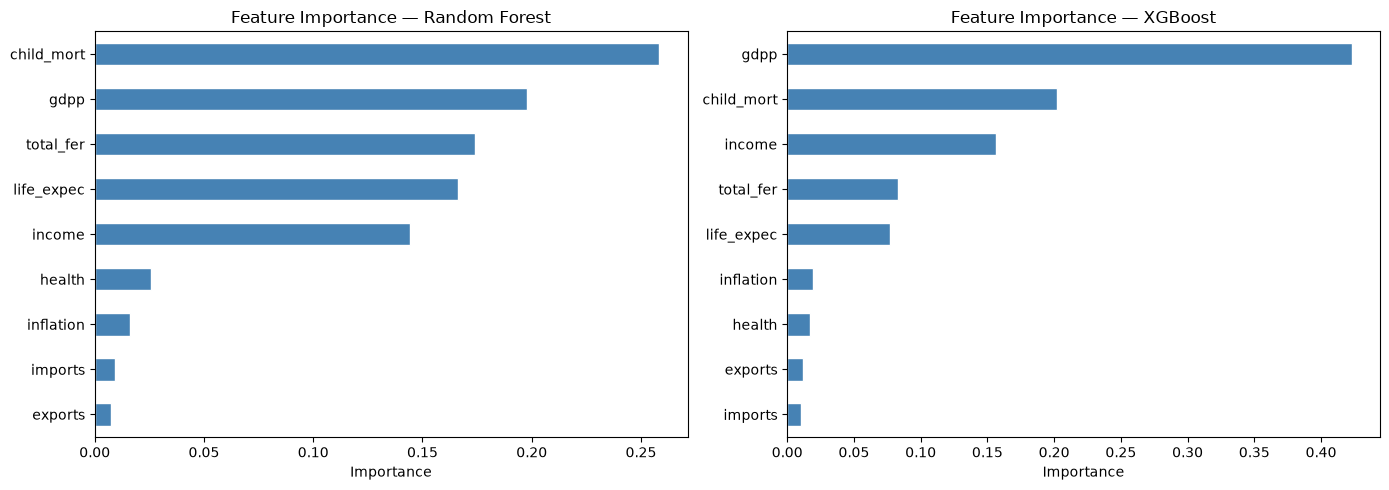

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, clf, title in zip(axes,
                            [rf_clf, xgb_clf],
                            ['Random Forest', 'XGBoost']):
    imp = pd.Series(clf.feature_importances_, index=features).sort_values()
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## Summary

In [300]:
print("FINAL INSIGHTS")

for cluster_id, seg_name in segment_map.items():
    grp     = df[df['KMeans_Cluster'] == cluster_id]
    count   = len(grp)
    gdpp    = grp['gdpp'].mean()
    income  = grp['income'].mean()
    child_m = grp['child_mort'].mean()
    life_e  = grp['life_expec'].mean()
    print(f"\n  [{seg_name}]  ({count} countries)")
    print(f"    Avg GDP per capita : ${gdpp:,.0f}")
    print(f"    Avg Income         : ${income:,.0f}")
    print(f"    Avg Child Mortality: {child_m:.1f}")
    print(f"    Avg Life Expectancy: {life_e:.1f} yrs")

print()
print("  CLASSIFICATION PERFORMANCE SUMMARY")
for name, preds in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    print(f"  {name:<20} Accuracy: {acc:.4f}  |  F1 (macro): {f1:.4f}")

FINAL INSIGHTS

  [Developed Markets]  (36 countries)
    Avg GDP per capita : $42,494
    Avg Income         : $45,672
    Avg Child Mortality: 5.0
    Avg Life Expectancy: 80.1 yrs

  [Underdeveloped Markets]  (47 countries)
    Avg GDP per capita : $1,922
    Avg Income         : $3,942
    Avg Child Mortality: 93.0
    Avg Life Expectancy: 59.2 yrs

  [Developing Markets]  (84 countries)
    Avg GDP per capita : $6,486
    Avg Income         : $12,306
    Avg Child Mortality: 21.9
    Avg Life Expectancy: 72.8 yrs

  CLASSIFICATION PERFORMANCE SUMMARY
  Random Forest        Accuracy: 1.0000  |  F1 (macro): 1.0000
  XGBoost              Accuracy: 0.9412  |  F1 (macro): 0.9383


## Market Entry Scoring Tool

A utility function that classifies any new country into a market segment 
and returns an investment recommendation based on its socioeconomic profile.
This operationalises the clustering model into a reusable decision-support tool.

In [301]:
def market_entry_score(country_indicators: dict):
    input_df = pd.DataFrame([country_indicators])
    input_scaled = scaler.transform(input_df)
    
    cluster = rf_clf.predict(input_scaled)[0]
    proba   = rf_clf.predict_proba(input_scaled)[0]
    segment = segment_map[cluster]
    confidence = proba.max() * 100
    
    recommendations = {
        'Developed Markets':       'Saturated — high competition, premium positioning required.',
        'Developing Markets':      'High opportunity — growing middle class, infrastructure investment viable.',
        'Underdeveloped Markets':  'High risk, high impact — focus on essential services, long-term horizon needed.',
    }
    
    print(f"Segment      : {segment}")
    print(f"Confidence   : {confidence:.1f}%")
    print(f"Recommendation: {recommendations[segment]}")
    return segment, confidence

# Example
market_entry_score({
    'child_mort': 45,
    'exports':    22,
    'health':     6,
    'imports':    28,
    'income':     4500,
    'inflation':  7,
    'life_expec': 65,
    'total_fer':  3.2,
    'gdpp':       3200,
})

Segment      : Developing Markets
Confidence   : 78.0%
Recommendation: High opportunity — growing middle class, infrastructure investment viable.


('Developing Markets', np.float64(78.0))

## Conclusion

### Key Findings

`gdpp`, `income`, `child_mort`, and `life_expec` are the dominant features 
driving segment boundaries — consistent with development economics literature. 
Botswana and Kuwait emerged as boundary cases where wealth metrics and human 
development indicators diverge, highlighting the real-world complexity that 
hard cluster assignments cannot fully capture.

### Dataset Limitation

It is important to acknowledge that this dataset was not originally designed for 
a Customer Intelligence System task. With 167 rows, 9 purely socioeconomic 
features, and no customer-level behavioral data or pre-existing labels, it does 
not naturally support the classification and segmentation tasks typically 
associated with customer analytics.